In [1]:
import pandas as pd
from pathlib import Path

CLEANED_DIR = Path("../data/cleaned")

customers = pd.read_csv(
    CLEANED_DIR / "customer_features.csv"
)

print("Customer feature dataset loaded successfully.")
print("Shape:", customers.shape)

Customer feature dataset loaded successfully.
Shape: (8000, 35)


In [2]:
plan_distribution = customers["current_plan"].value_counts()

print(plan_distribution)

current_plan
PLAN01    3368
PLAN02    3018
PLAN03    1614
Name: count, dtype: int64


In [4]:
subscription_plans = pd.read_csv(
    CLEANED_DIR / "subscription_plans.csv"
)

print(subscription_plans)

  plan_id plan_name  monthly_price    video_quality  max_devices  \
0  PLAN01     Basic           6.99        720p (HD)            1   
1  PLAN02  Standard          15.49  1080p (Full HD)            2   
2  PLAN03   Premium          22.99    4K (Ultra HD)            4   

  advertisements  
0            Yes  
1             No  
2             No  


In [5]:
plan_names = subscription_plans.set_index(
    "plan_id"
)["plan_name"]

customers["current_plan_name"] = (
    customers["current_plan"].map(plan_names)
)

print(customers[[
    "customer_id",
    "current_plan",
    "current_plan_name"
]].head(10))

  customer_id current_plan current_plan_name
0  CUST000744       PLAN03           Premium
1  CUST001502       PLAN01             Basic
2  CUST005383       PLAN01             Basic
3  CUST004708       PLAN02          Standard
4  CUST005877       PLAN03           Premium
5  CUST003762       PLAN02          Standard
6  CUST007892       PLAN02          Standard
7  CUST002317       PLAN01             Basic
8  CUST005609       PLAN02          Standard
9  CUST000519       PLAN03           Premium


In [6]:
plan_distribution = customers["current_plan_name"].value_counts()

plan_percentage = (
    plan_distribution
    / len(customers)
    * 100
)

print(plan_percentage)

current_plan_name
Basic       42.100
Standard    37.725
Premium     20.175
Name: count, dtype: float64


In [7]:
print("Average watch time:",
      customers["total_watch_time_minutes"].mean())

print("Average viewing sessions:",
      customers["total_viewing_sessions"].mean())

print("Average completion percentage:",
      customers["average_completion_percentage"].mean())

Average watch time: 408.014375
Average viewing sessions: 8.30275
Average completion percentage: 70.22406610428347


In [8]:
plan_engagement = customers.groupby(
    "current_plan_name"
)[[
    "total_watch_time_minutes",
    "total_viewing_sessions",
    "average_completion_percentage"
]].mean()

print(plan_engagement)

                   total_watch_time_minutes  total_viewing_sessions  \
current_plan_name                                                     
Basic                            412.305819                8.401722   
Premium                          402.776952                8.122677   
Standard                         406.026176                8.288602   

                   average_completion_percentage  
current_plan_name                                 
Basic                                  70.257393  
Premium                                69.816461  
Standard                               70.404858  


In [11]:
churn_distribution = customers["churn_flag"].value_counts()

print(churn_distribution)

KeyError: 'churn_flag'

In [10]:
churn_labels = pd.read_csv(
    CLEANED_DIR / "churn_labels.csv"
)

print("Churn labels loaded successfully.")
print(churn_labels.head())
print("Shape:", churn_labels.shape)

Churn labels loaded successfully.
  customer_id  churned  churn_date   churn_reason
0  CUST000001    False         NaN            NaN
1  CUST000002    False         NaN            NaN
2  CUST000003     True  2026-04-20  Too expensive
3  CUST000004    False         NaN            NaN
4  CUST000005    False         NaN            NaN
Shape: (8000, 4)


In [12]:
customer_analytics = customers.merge(
    churn_labels[["customer_id", "churned"]],
    on="customer_id",
    how="left"
)

print("Customer analytics shape:", customer_analytics.shape)

print(
    customer_analytics[[
        "customer_id",
        "current_plan_name",
        "churned"
    ]].head(10)
)

Customer analytics shape: (8000, 37)
  customer_id current_plan_name  churned
0  CUST000744           Premium    False
1  CUST001502             Basic    False
2  CUST005383             Basic    False
3  CUST004708          Standard     True
4  CUST005877           Premium    False
5  CUST003762          Standard    False
6  CUST007892          Standard    False
7  CUST002317             Basic    False
8  CUST005609          Standard    False
9  CUST000519           Premium    False


In [13]:
churn_count = customer_analytics["churned"].sum()

total_customers = len(customer_analytics)

churn_rate = (
    churn_count / total_customers
) * 100

print("Churned customers:", churn_count)
print("Total customers:", total_customers)
print("Overall churn rate:", churn_rate)

Churned customers: 1991
Total customers: 8000
Overall churn rate: 24.887500000000003


In [14]:
churn_by_plan = customer_analytics.groupby(
    "current_plan_name"
)["churned"].mean() * 100

print(churn_by_plan)

current_plan_name
Basic       26.306413
Premium     22.490706
Standard    24.585818
Name: churned, dtype: float64


In [15]:
engagement_by_churn = customer_analytics.groupby(
    "churned"
)[[
    "total_watch_time_minutes",
    "total_viewing_sessions",
    "average_completion_percentage"
]].mean()

print(engagement_by_churn)

         total_watch_time_minutes  total_viewing_sessions  \
churned                                                     
False                  416.328507                8.462806   
True                   382.921647                7.819689   

         average_completion_percentage  
churned                                 
False                        70.242858  
True                         70.167350  


In [16]:
payment_by_churn = customer_analytics.groupby(
    "churned"
)[[
    "failed_payment_count",
    "payment_failure_rate"
]].mean()

print(payment_by_churn)

         failed_payment_count  payment_failure_rate
churned                                            
False                0.823598              0.058727
True                 1.133601              0.086794


In [17]:
support_by_churn = customer_analytics[
    customer_analytics["average_support_satisfaction"].notna()
].groupby("churned")[
    "average_support_satisfaction"
].mean()

print(support_by_churn)

churned
False    3.332262
True     2.997535
Name: average_support_satisfaction, dtype: float64


In [18]:
churn_by_segment = customer_analytics.groupby(
    "customer_segment"
)["churned"].mean() * 100

print(churn_by_segment)

customer_segment
Corporate Bundle    28.059701
Family              24.748996
Individual          25.034200
Student             22.268908
Name: churned, dtype: float64


In [19]:
print("Overall churn rate:",
      round(churn_rate, 2), "%")

print("\nChurn by plan:")
print(churn_by_plan.round(2))

print("\nChurn by customer segment:")
print(churn_by_segment.round(2))

print("\nEngagement by churn status:")
print(engagement_by_churn.round(2))

print("\nPayment failure rate by churn status:")
print(
    (payment_by_churn["payment_failure_rate"] * 100).round(2)
)

print("\nSupport satisfaction by churn status:")
print(support_by_churn.round(2))

Overall churn rate: 24.89 %

Churn by plan:
current_plan_name
Basic       26.31
Premium     22.49
Standard    24.59
Name: churned, dtype: float64

Churn by customer segment:
customer_segment
Corporate Bundle    28.06
Family              24.75
Individual          25.03
Student             22.27
Name: churned, dtype: float64

Engagement by churn status:
         total_watch_time_minutes  total_viewing_sessions  \
churned                                                     
False                      416.33                    8.46   
True                       382.92                    7.82   

         average_completion_percentage  
churned                                 
False                            70.24  
True                             70.17  

Payment failure rate by churn status:
churned
False    5.87
True     8.68
Name: payment_failure_rate, dtype: float64

Support satisfaction by churn status:
churned
False    3.33
True     3.00
Name: average_support_satisfaction, dtype: f

In [20]:
churn_by_plan_df = churn_by_plan.reset_index()

print(churn_by_plan_df)

  current_plan_name    churned
0             Basic  26.306413
1           Premium  22.490706
2          Standard  24.585818


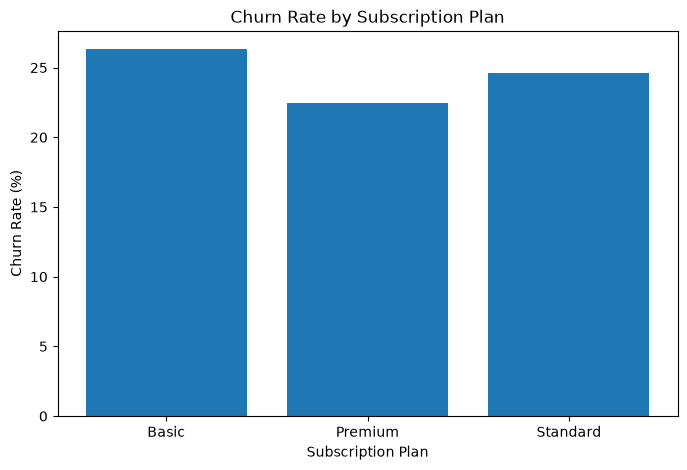

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    churn_by_plan.index,
    churn_by_plan.values
)

plt.xlabel("Subscription Plan")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Subscription Plan")

plt.show()

## Key Business Insights

- The overall customer churn rate is 24.89%.
- Basic customers have the highest churn rate at 26.31%, while Premium customers have the lowest at 22.49%.
- Churned customers have lower average watch time and fewer viewing sessions than retained customers.
- Churned customers have a higher average payment failure rate (8.68%) compared with retained customers (5.87%).
- Among customers with recorded support satisfaction, churned customers have lower average satisfaction (3.00) than retained customers (3.33).
- Corporate Bundle customers have the highest churn rate at 28.06%, while Student customers have the lowest at 22.27%.
- These findings show associations with churn and should not be interpreted as proof of causation.
